# Capacity ablation: retrieval performance

MRR for clean, two-second queries from the shared 1,000-query capacity evaluation set.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [2]:
database_sizes = [10_000, 25_000, 50_000, 100_000]
mrr = {
    "Tiny":   [0.9817, 0.9584, 0.9153, 0.8086],
    "Small":  [0.9902, 0.9722, 0.9767, 0.9509],
    "Medium": [1.0000, 1.0000, 0.9920, 0.9880],
}

for decoder, values in mrr.items():
    print(f"{decoder:>6}: " + ", ".join(f"{value:.4f}" for value in values))

  Tiny: 0.9817, 0.9584, 0.9153, 0.8086
 Small: 0.9902, 0.9722, 0.9767, 0.9509
Medium: 1.0000, 1.0000, 0.9920, 0.9880


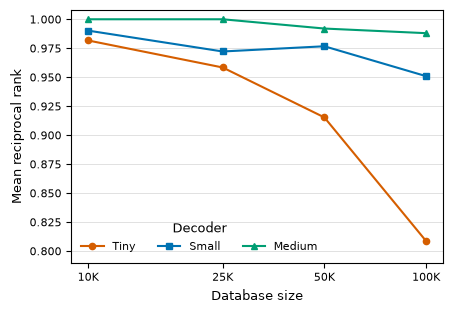

In [ ]:
styles = {
    "Tiny":   {"color": "#D55E00", "marker": "o"},
    "Small":  {"color": "#0072B2", "marker": "s"},
    "Medium": {"color": "#009E73", "marker": "^"},
}

fig, ax = plt.subplots(figsize=(4.6, 3.2))
for decoder, values in mrr.items():
    ax.plot(
        database_sizes,
        values,
        label=decoder,
        linewidth=1.5,
        markersize=4.5,
        **styles[decoder],
    )

ax.set_xscale("log")
ax.xaxis.set_major_locator(FixedLocator(database_sizes))
ax.xaxis.set_major_formatter(FixedFormatter(["10K", "25K", "50K", "100K"]))
ax.xaxis.set_minor_locator(FixedLocator([]))
ax.set_xlabel("Database size")
ax.set_ylabel("Mean reciprocal rank")
ax.set_ylim(0.79, 1.008)
ax.grid(axis="y", color="#d0d0d0", linewidth=0.7, alpha=0.65)
ax.legend(title="Decoder", frameon=False, ncol=3, loc="lower left")
fig.tight_layout()

output_root = Path("ablations")
output_root.mkdir(exist_ok=True)
fig.savefig(output_root / "capacity-mrr.pdf", bbox_inches="tight")
fig.savefig(output_root / "capacity-mrr.png", dpi=300, bbox_inches="tight")
plt.show()